In [4]:
import numpy as np
import re
from pathlib import Path

data_dir = Path("trel_mode/thread_test")
p = np.array([0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018, 0.019])
L = np.array([5, 7, 9, 13, 19])

def load_trel_stats(path):
    text = path.read_text()
    trel_match = re.search(r"trel_stats\s*=\s*\[([^\]]+)\]", text)
    samps_match = re.search(r"samps\s*=\s*\[([^\]]+)\]", text)
    l_match = re.search(r"^L\s*=\s*(\d+)\s*$", text, re.MULTILINE)
    p_match = re.search(r"^p\s*=\s*([0-9.]+)\s*$", text, re.MULTILINE)
    if trel_match is None or samps_match is None or l_match is None or p_match is None:
        raise ValueError(f"Could not parse trel stats from {path}")

    trel_stats = np.fromstring(trel_match.group(1), sep=" ")
    samps = np.fromstring(samps_match.group(1), sep=" ")[0]
    mean = trel_stats[0]
    std = trel_stats[1]
    sem = std / np.sqrt(samps)
    return int(l_match.group(1)), float(p_match.group(1)), mean, sem

t_rel = np.full((len(L), len(p)), np.nan)
t_rel_error = np.full_like(t_rel, np.nan)

for path in sorted(data_dir.glob("2d_trel_*.txt")):
    cur_l, cur_p, mean, error = load_trel_stats(path)
    l_idx = np.where(L == cur_l)[0]
    p_idx = np.where(np.isclose(p, cur_p))[0]
    if l_idx.size and p_idx.size:
        t_rel[l_idx[0], p_idx[0]] = mean
        t_rel_error[l_idx[0], p_idx[0]] = error

if np.isnan(t_rel).any() or np.isnan(t_rel_error).any():
    raise ValueError("Missing trel data for at least one plotted (L, p) point")

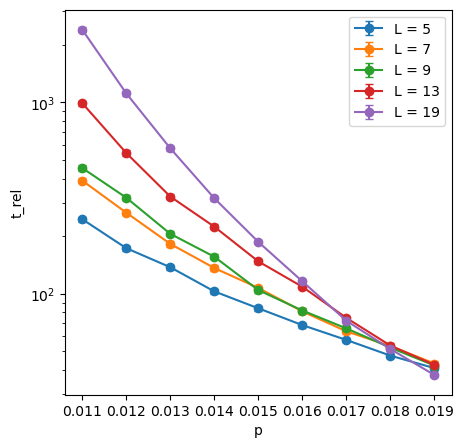

In [5]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.figure(figsize=(5, 5))
for l_idx, cur_l in enumerate(L):
    plt.errorbar(p, t_rel[l_idx], yerr=t_rel_error[l_idx], fmt='o-', capsize=3, label=f'L = {cur_l}')
    
plt.yscale('log')
plt.xlabel('p')
plt.ylabel('t_rel')
plt.legend()
plt.show()

In [3]:
p = np.tile(np.array([0.158, 0.16, 0.162, 0.164, 0.166, 0.168, 0.17, 0.172]), 4)
L = np.repeat(np.array([4, 5, 6, 7]), 8)
rate = error_rate.flatten()
n = 4 * 10**4
rate_error = np.array([])
for i in range(len(p)):
    se = (rate[i]*(1-rate[i])/n)**(1/2)
    rate_error = np.append(rate_error, se)

In [4]:
# Define the model
def model(pL, pc, nu, A, B, C):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [0.16917956 1.55835959 0.48750213 4.38685634 4.44024393]
Parameter standard deviations: [3.46052300e-04 9.31517979e-02 4.54881049e-03 2.90713110e-01
 2.45416331e+00]


25.05180183301977

In [5]:
# Define the model
def model(pL, pc, nu, A, B, C, D):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu)) + D*((p-pc)**3)*(L**(3/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 1400.

In [7]:
# Define the model
def model(pL, pc, nu, A, B, C, E, mu):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu)) + E*(L**(-1/mu))

lower_bounds = [-np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, 0]
upper_bounds = [ np.inf,  np.inf,  np.inf,  np.inf,  np.inf,  np.inf, 100]

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, p0=[0.2, 1.5, 0.25, 0, 0, 0, 1], full_output=True, sigma=rate_error, absolute_sigma=True, bounds=(lower_bounds, upper_bounds))

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [ 0.65365671  1.34971846  1.14826578  1.56452687 -5.18613924 -0.34269411
 99.99999043]
Parameter standard deviations: [9.76327070e-03 2.99372267e-01 2.92635434e+02 8.74972246e-02
 3.08466258e+00 2.92607372e+02 8.56792366e+04]


np.float64(22.20382166839723)

In [8]:
# Define the model
def model(pL, pc, nu, A, B, C, D, E, mu):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu)) + D*((p-pc)**3)*(L**(3/nu)) + E*(L**(-1/mu))

lower_bounds = [-np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, 0]
upper_bounds = [ np.inf,  np.inf,  np.inf,  np.inf,  np.inf,  np.inf,  np.inf, 100]

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, p0=[0.2, 1.5, 0.25, 0, 0, 0, 0, 1], full_output=True, sigma=rate_error, absolute_sigma=True, bounds=(lower_bounds, upper_bounds))

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [  0.65404509   1.34448582   1.30804383   1.55235428  -5.36404565
 -21.74404279  -0.50298455  99.99988433]
Parameter standard deviations: [5.69360690e-03 1.77236538e-01 1.68973340e+02 6.08258078e-02
 3.31270470e+00 2.65007526e+01 1.68956754e+02 3.37208319e+04]


np.float64(21.96701507513171)

In [4]:
px = 0.16
w1 = np.log(1/px - 1)
print(w1)

1.6582280766035324
